# When Does Tactical Context Matter?

The tactical model adds team style deltas to the baseline (pre-quality only).
But does it help equally for all transfers — or more when the tactical change is large?

---
## Setup

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from itertools import combinations
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Design system ──
BG = '#FAFAFA'; GRID = '#EDEDED'; AXIS = '#D5D5D5'
TEXT = '#2D2D2D'; SUBTEXT = '#737373'
C_BASELINE = '#BF5B3F'; C_TACTICAL = '#2E74B5'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SUBTEXT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 16,
    'axes.labelsize': 9.5, 'axes.grid': False,
    'text.color': TEXT, 'xtick.color': SUBTEXT, 'ytick.color': SUBTEXT,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'font.family': 'sans-serif', 'figure.dpi': 140,
    'axes.spines.top': False, 'axes.spines.right': False,
})

---
## Data & Models

In [4]:
DATA_DIR = "../../../thesis_data/processed_data/thesis_model_dataset/active/"
df = pd.read_parquet(DATA_DIR + "within_league_transfers_v5.parquet")
mf = df[df["from_position"] == "Midfielder"].copy()

QUALITIES = [
    "Involvement", "Active defence", "Intelligent defence", "Progression",
    "Passing quality", "Effectiveness", "Providing teammates", "Box threat",
]
TQ_NAMES = ["ATTACK", "ATTACKING_TRANSITION", "CHANCE_CREATION",
            "DEFENCE", "DEFENSIVE_TRANSITION", "OUTCOME", "PENETRATION"]

for q in QUALITIES:
    mf['delta_' + q] = mf['to_' + q] - mf['from_' + q]
for tq in TQ_NAMES:
    mf['delta_tq_' + tq] = mf['to_q_' + tq] - mf['from_q_proj_' + tq]

delta_tq = ['delta_tq_' + tq for tq in TQ_NAMES]
cols_needed = ['from_' + q for q in QUALITIES] + ['delta_' + q for q in QUALITIES] + delta_tq
mf = mf.dropna(subset=cols_needed)

train, test = train_test_split(mf, test_size=0.2, random_state=42)
print(f'Midfielders: {len(mf):,}  (train: {len(train):,}, test: {len(test):,})')

Midfielders: 4,888  (train: 3,910, test: 978)


In [5]:
# ── Train baseline + exhaustive search per quality ──
best_models = {}
for q in QUALITIES:
    y_train = train['delta_' + q]
    naive = sm.OLS(y_train, sm.add_constant(train[['from_' + q]])).fit()

    best_r2, best_combo, best_model = -999, None, None
    for k in range(1, 8):
        for combo in combinations(delta_tq, k):
            feat = ['from_' + q] + list(combo)
            m = sm.OLS(y_train, sm.add_constant(train[feat])).fit()
            r2 = r2_score(test['delta_' + q], m.predict(sm.add_constant(test[feat])))
            if r2 > best_r2:
                best_r2, best_combo, best_model = r2, list(combo), m

    best_models[q] = {'naive': naive, 'tactical': best_model, 'deltas': best_combo}
    deltas_short = [c.replace('delta_tq_', '') for c in best_combo]
    print(f'{q:<22} Deltas: {", ".join(deltas_short)}')

Involvement            Deltas: ATTACK, ATTACKING_TRANSITION, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
Active defence         Deltas: DEFENCE, OUTCOME
Intelligent defence    Deltas: CHANCE_CREATION, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
Progression            Deltas: ATTACK, ATTACKING_TRANSITION, DEFENCE, DEFENSIVE_TRANSITION
Passing quality        Deltas: ATTACK, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
Effectiveness          Deltas: ATTACK, ATTACKING_TRANSITION, DEFENCE, OUTCOME, PENETRATION
Providing teammates    Deltas: ATTACK, DEFENCE, OUTCOME
Box threat             Deltas: ATTACK, CHANCE_CREATION, DEFENCE, OUTCOME


---
## Segment Definitions

Two ways to split the test set:

1. **Tactical distance** — L2 norm of all 7 team quality deltas, split into terciles
2. **Transfer direction** — using Outcome delta as proxy for table position: Higher→Lower table (Δ < −0.5), Similar (|Δ| ≤ 0.5), Lower→Higher table (Δ > 0.5)

In [6]:
test = test.copy()

# Tactical distance: L2 norm of all 7 delta_tq
test['tq_distance'] = np.sqrt(sum(test['delta_tq_' + tq]**2 for tq in TQ_NAMES))
test['tq_tercile'] = pd.qcut(test['tq_distance'], 3, labels=['Small Δ', 'Medium Δ', 'Large Δ'])

# Transfer direction via Outcome delta
test['transfer_type'] = pd.cut(
    test['delta_tq_OUTCOME'],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=['Higher→Lower table', 'Similar', 'Lower→Higher table']
)

print('By tactical distance:')
for t in ['Small Δ', 'Medium Δ', 'Large Δ']:
    s = test[test['tq_tercile'] == t]
    print(f'  {t}: n={len(s)}, range={s["tq_distance"].min():.2f}–{s["tq_distance"].max():.2f}')

print(f'\nBy transfer direction:')
print(test['transfer_type'].value_counts().sort_index().to_string())

By tactical distance:
  Small Δ: n=326, range=0.48–1.74
  Medium Δ: n=326, range=1.75–2.47
  Large Δ: n=326, range=2.47–8.43

By transfer direction:
transfer_type
Higher→Lower table    254
Similar               335
Lower→Higher table    389


In [7]:
def segment_r2(quality, segment_col, segment_val):
    bm = best_models[quality]
    subset = test[test[segment_col] == segment_val]
    y = subset['delta_' + quality]
    r2_n = r2_score(y, bm['naive'].predict(sm.add_constant(subset[['from_' + quality]])))
    feat = ['from_' + quality] + bm['deltas']
    r2_t = r2_score(y, bm['tactical'].predict(sm.add_constant(subset[feat])))
    return r2_n, r2_t

---
## R² Gain by Tactical Distance — Per Quality

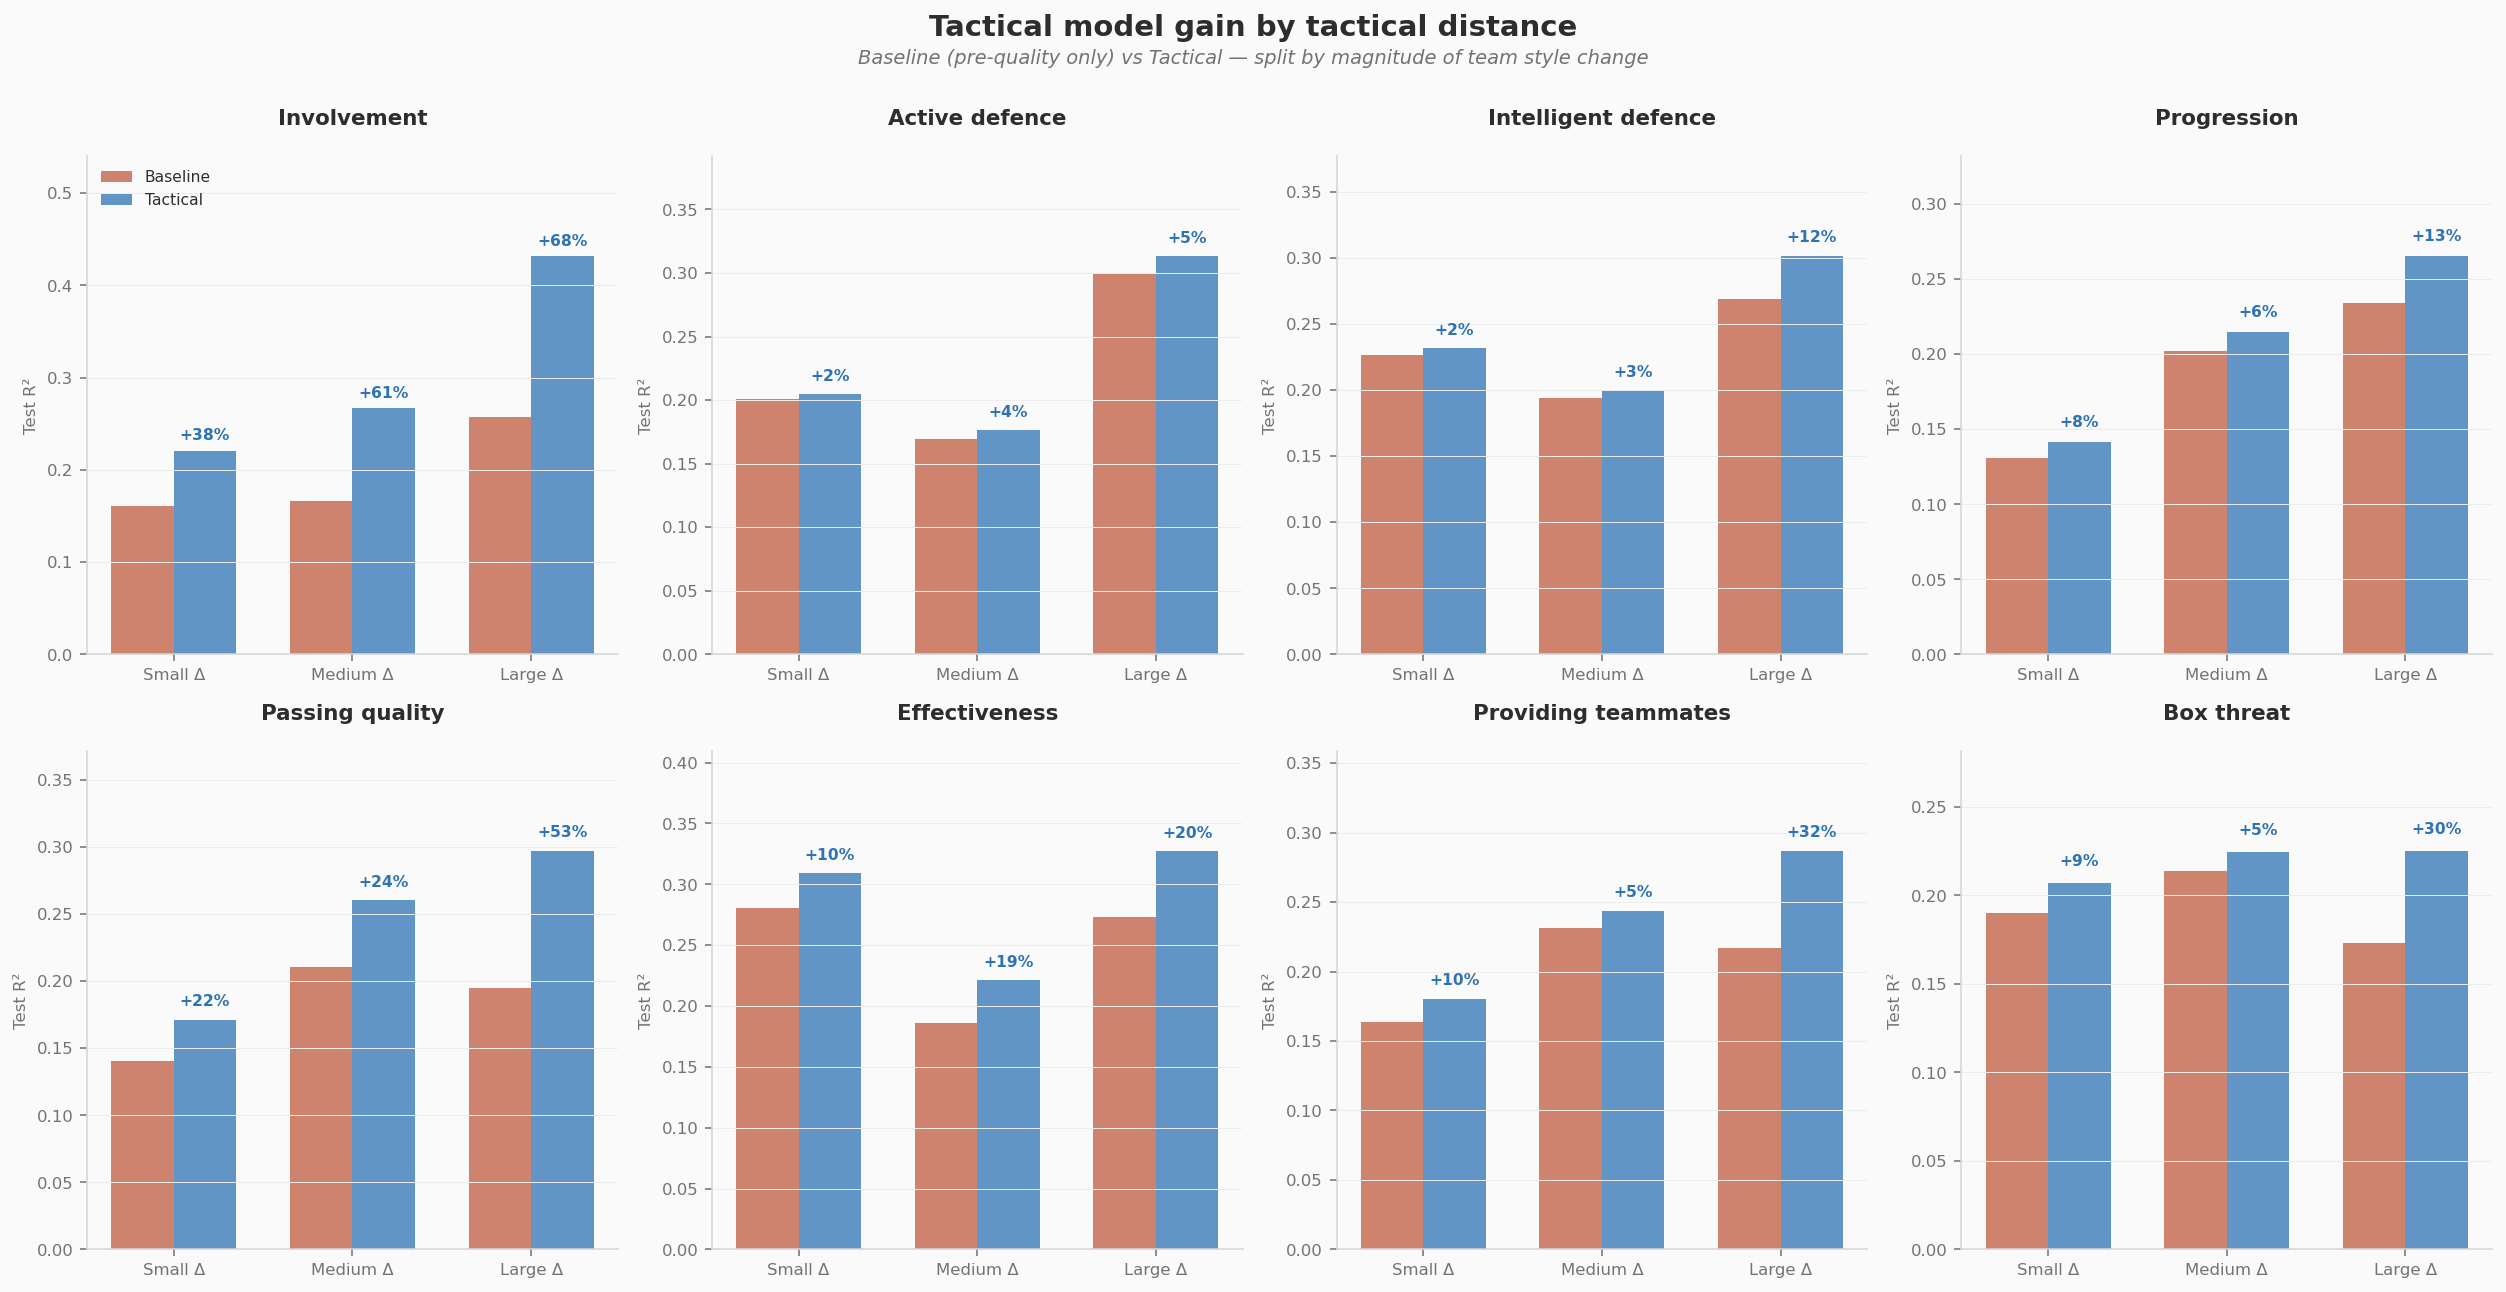

In [8]:
segments = ['Small Δ', 'Medium Δ', 'Large Δ']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Tactical model gain by tactical distance', fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Baseline (pre-quality only) vs Tactical — split by magnitude of team style change',
         ha='center', fontsize=10, color=SUBTEXT, style='italic')

for idx, q in enumerate(QUALITIES):
    ax = axes[idx // 4, idx % 4]
    naive_vals, tact_vals = zip(*[segment_r2(q, 'tq_tercile', s) for s in segments])

    x = np.arange(3)
    w = 0.35
    ax.bar(x - w/2, naive_vals, w, color=C_BASELINE, alpha=0.75, label='Baseline')
    ax.bar(x + w/2, tact_vals, w, color=C_TACTICAL, alpha=0.75, label='Tactical')

    for i, (n, t) in enumerate(zip(naive_vals, tact_vals)):
        pct = (t - n) / abs(n) * 100 if n != 0 else 0
        ax.text(i + w/2, t + 0.008, f'+{pct:.0f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color=C_TACTICAL)

    ax.set_title(q, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(segments, fontsize=8.5)
    ax.set_ylabel('Test R²', fontsize=8.5)
    ax.set_ylim(0, max(max(tact_vals), max(naive_vals)) * 1.25)
    ax.grid(axis='y', color=GRID, linewidth=0.5)
    if idx == 0:
        ax.legend(frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## R² Gain by Transfer Direction (Table Position) — Per Quality

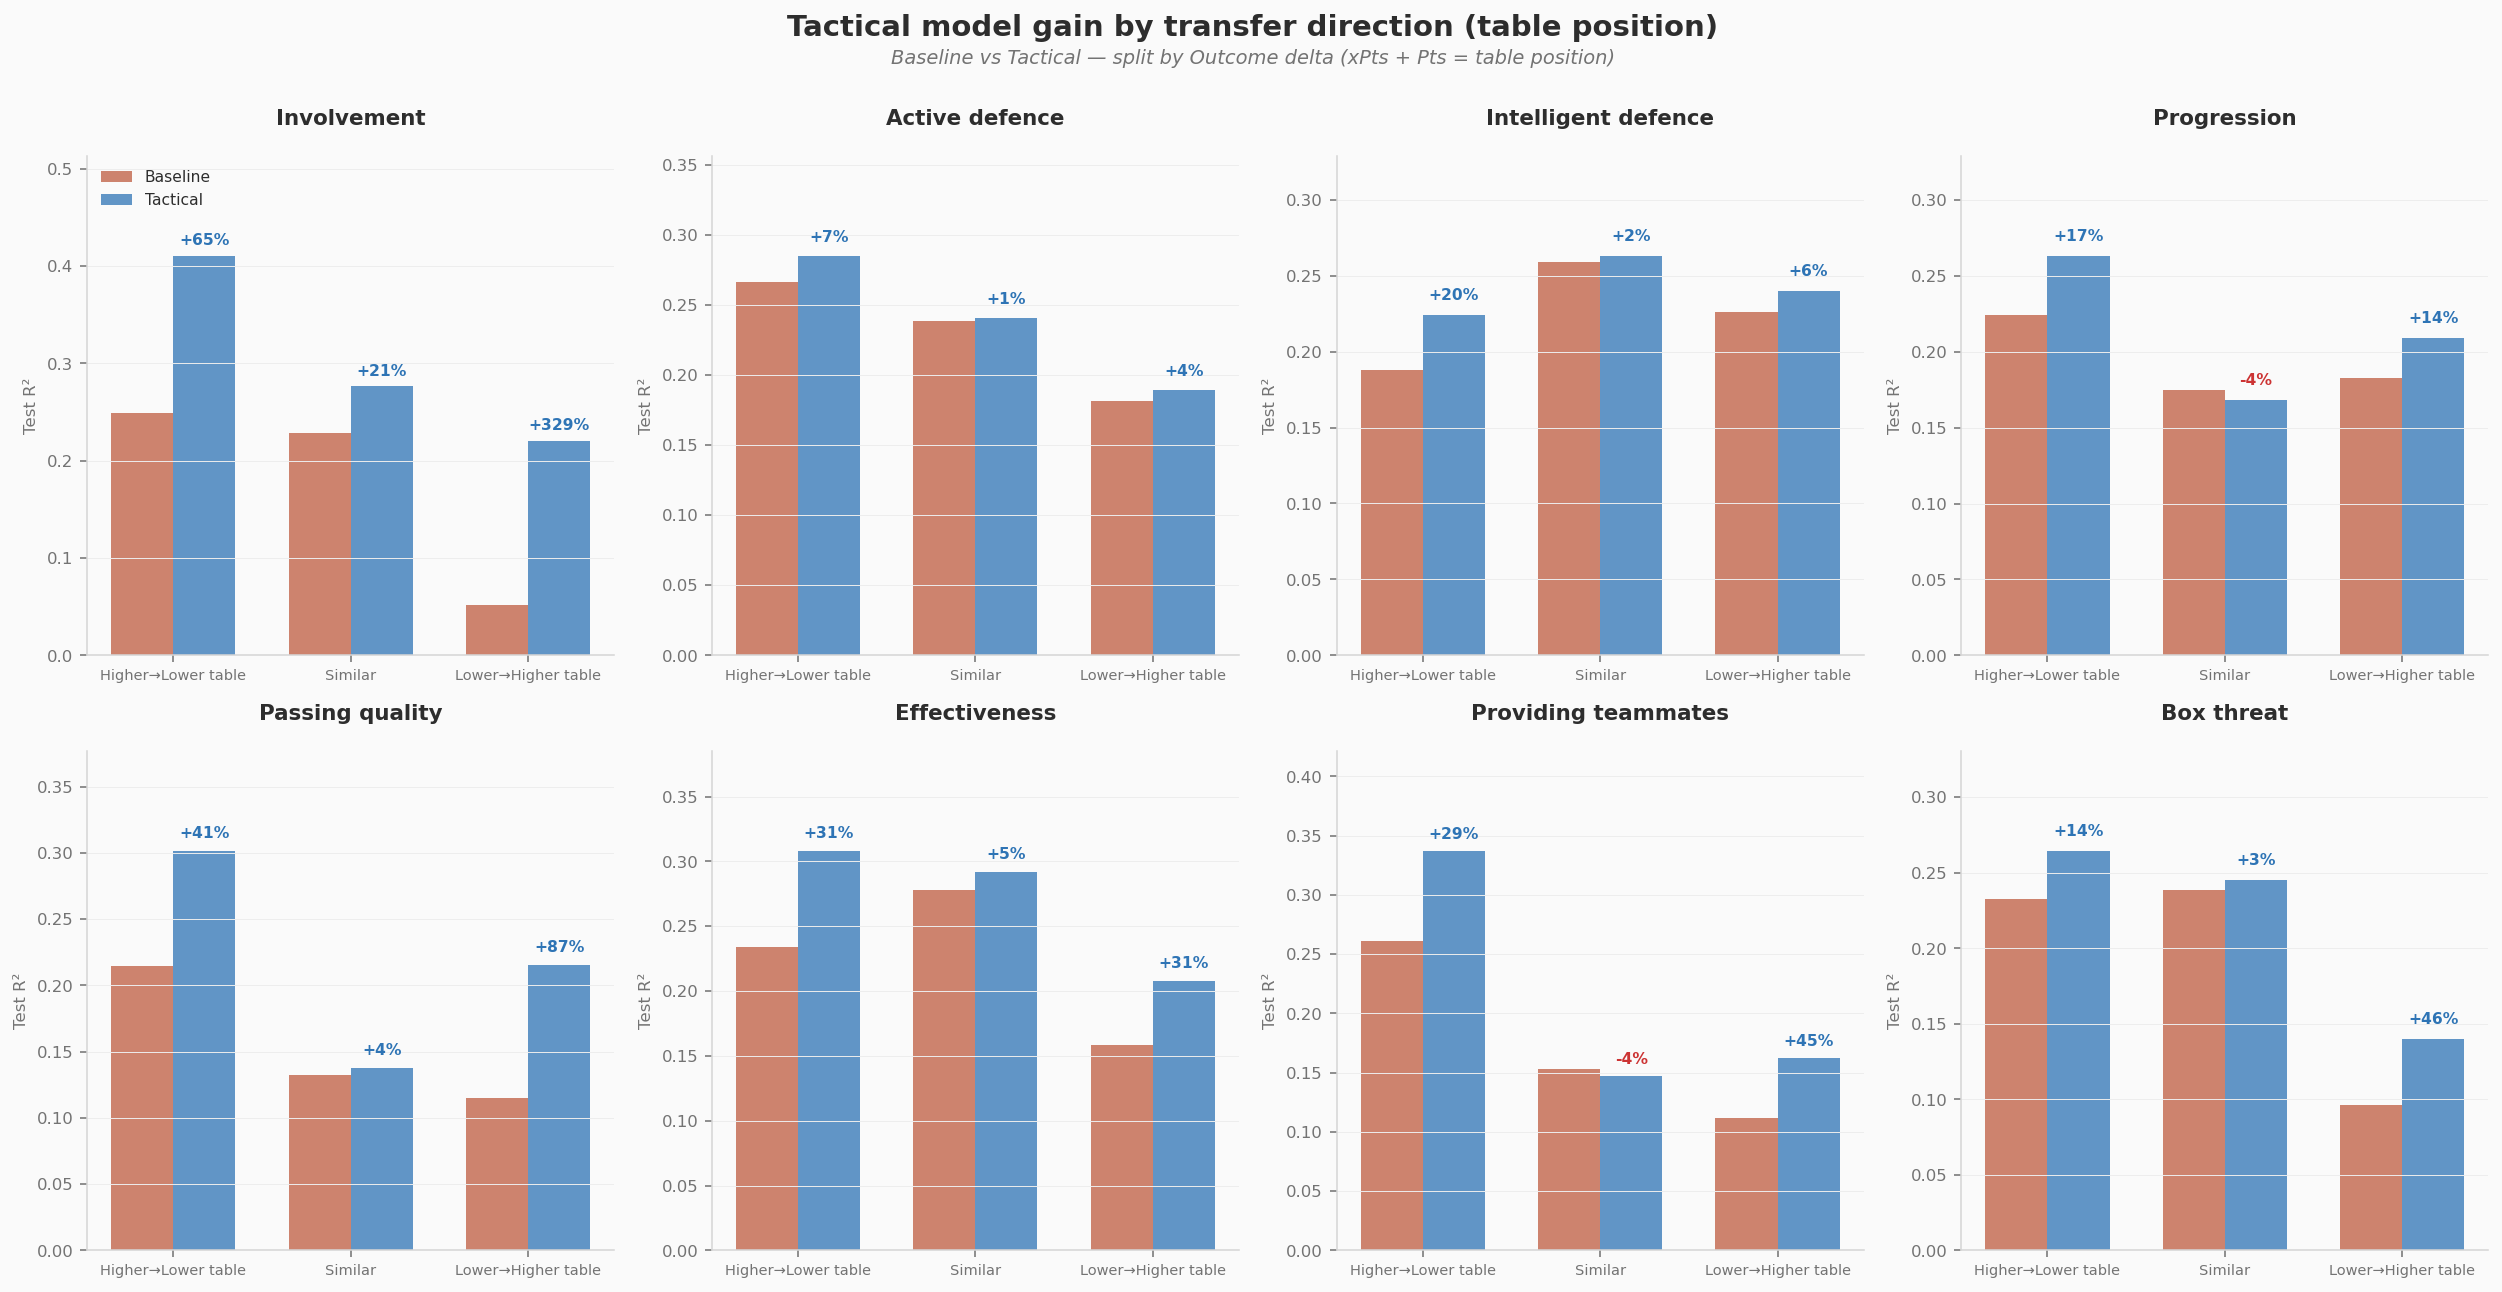

In [9]:
segments = ['Higher→Lower table', 'Similar', 'Lower→Higher table']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Tactical model gain by transfer direction (table position)', fontsize=15, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Baseline vs Tactical — split by Outcome delta (xPts + Pts = table position)',
         ha='center', fontsize=10, color=SUBTEXT, style='italic')

for idx, q in enumerate(QUALITIES):
    ax = axes[idx // 4, idx % 4]
    naive_vals, tact_vals = zip(*[segment_r2(q, 'transfer_type', s) for s in segments])

    x = np.arange(3)
    w = 0.35
    ax.bar(x - w/2, naive_vals, w, color=C_BASELINE, alpha=0.75, label='Baseline')
    ax.bar(x + w/2, tact_vals, w, color=C_TACTICAL, alpha=0.75, label='Tactical')

    for i, (n, t) in enumerate(zip(naive_vals, tact_vals)):
        pct = (t - n) / abs(n) * 100 if n != 0 else 0
        color = C_TACTICAL if pct > 0 else '#CC3333'
        ax.text(i + w/2, max(t, 0) + 0.008, f'{pct:+.0f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color=color)

    ax.set_title(q, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(segments, fontsize=7.5)
    ax.set_ylabel('Test R²', fontsize=8.5)
    ax.set_ylim(0, max(max(tact_vals), max(naive_vals)) * 1.25)
    ax.grid(axis='y', color=GRID, linewidth=0.5)
    if idx == 0:
        ax.legend(frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## Key Takeaways

- The tactical model gains **consistently more** when the tactical change is large (all 8 qualities)
- For **similar-level** transfers, the baseline already captures most variance — tactical context adds almost nothing
- **Involvement** and **Passing quality** show the largest differential: tactical context matters 3–4x more for big moves
- The pattern holds both for overall tactical distance and directional (table position) splits
- Defensive qualities (Active/Intelligent defence) gain least regardless of segment — they're dominated by regression to the mean